In [1]:
!pip install tensorflow tensorflow-hub


In [11]:
# -------------------------
# 🔹 Upload Content and Style Images
# -------------------------
from google.colab import files

print("Please upload 2 images: first for CONTENT, second for STYLE.")
uploaded = files.upload()


Please upload 2 images: first for CONTENT, second for STYLE.


Saving hyperrealitic-AI-generated-portrait-of-a-women.jpg to hyperrealitic-AI-generated-portrait-of-a-women (1).jpg
Saving 902914.jpg to 902914 (1).jpg


In [12]:
# -------------------------
# 🔹 Choose content and style images from uploaded files
# -------------------------
uploaded_list = list(uploaded.keys())

# First image is content, second is style
content_image_path = uploaded_list[0]
style_image_path = uploaded_list[1]

print("Content Image:", content_image_path)
print("Style Image:", style_image_path)


Content Image: hyperrealitic-AI-generated-portrait-of-a-women (1).jpg
Style Image: 902914 (1).jpg


In [13]:
# -------------------------
# 🔹 Import Libraries and Define Image Loader
# -------------------------
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt

# Function to load and preprocess images
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (512, 512))
    img = img / 255.0
    return img[tf.newaxis, :]


In [14]:
# -------------------------
# 🔹 Load Content and Style Images
# -------------------------
content = load_image(content_image_path)
style = load_image(style_image_path)


In [15]:
# -------------------------
# 🔹 Load Pre-trained Neural Style Transfer Model
# -------------------------
model = hub.load("https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2")


In [16]:
# -------------------------
# 🔹 Apply Style Transfer
# -------------------------
stylized_image = model(content, style)[0]


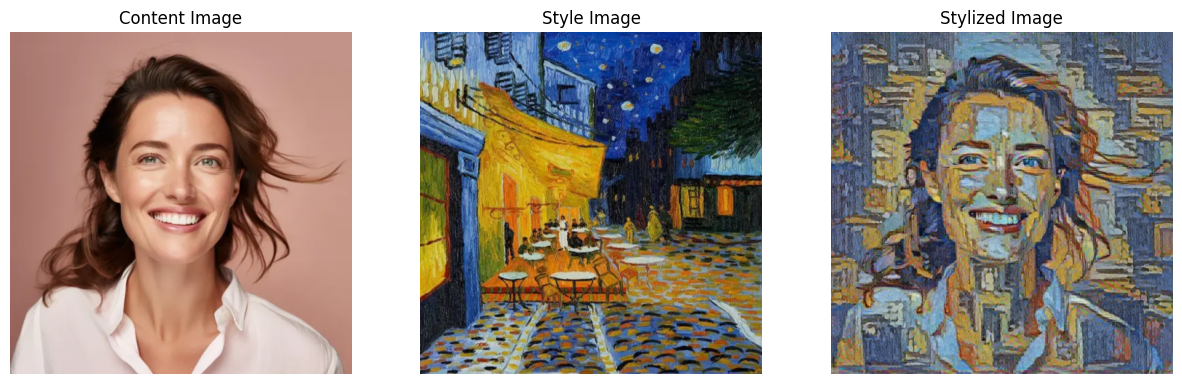

In [17]:
# -------------------------
# 🔹 Display Content, Style, and Stylized Image
# -------------------------
plt.figure(figsize=(15,5))

# Content Image
plt.subplot(1,3,1)
plt.imshow(content[0])
plt.axis("off")
plt.title("Content Image")

# Style Image
plt.subplot(1,3,2)
plt.imshow(style[0])
plt.axis("off")
plt.title("Style Image")

# Stylized Image
plt.subplot(1,3,3)
plt.imshow(stylized_image[0])
plt.axis("off")
plt.title("Stylized Image")

plt.show()
